## ============================================================
## FILE 03: EXPLORATORY_DATA_ANALYSIS.ipynb
## PROJECT: DARK PATTERN UX PROJECT
## DESCRIPTION: Data cleaning and validation for all the tables
## ============================================================

# Problem Definition:

## Objective of this project is to analyze the HealthFit fitness app data to identify how the March 15, 2024 pricing page redesign caused conversion rate drops, increased cancellations, and effected revenue.
## Performing Exploratory Data Analysis (EDA) on 4 tables (users, sessions, subscriptions, ab_test) using Python with Pandas and Matplotlib for data cleaning and visualization.

# Data Collection:

In [137]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read csv files:
users = pd.read_csv('users.csv')
subscriptions = pd.read_csv('subscriptions.csv')
sessions = pd.read_csv('sessions.csv')
ab_test = pd.read_csv('ab_test.csv')

print('='*100)
print('\t\t\t\tDATASET LOADED SUCCESSFULLY!')
print('='*100)
print('\n')

# Create Dictionary of all tables:
tables = {'users':users,
             'subscriptions':subscriptions,
             'sessions':sessions,
             'ab_test':ab_test
         }

# Check dataset size:
print('='*100)
print('\t\t\t\tSIZE OF THE  DATASET')
print('='*100)
for name, df in tables.items():
    print(f'{name.upper()} : {df.size}')

# Check dataset shape:
print('='*100)
print('\t\t\t\tSHAPE OF THE DATASET')
print('='*100)
for name,df in tables.items():
    print(f'{name.upper()} : {df.shape}')
print('='*100)

				DATASET LOADED SUCCESSFULLY!


				SIZE OF THE  DATASET
USERS : 18000
SUBSCRIPTIONS : 12600
SESSIONS : 105000
AB_TEST : 12000
				SHAPE OF THE DATASET
USERS : (3000, 6)
SUBSCRIPTIONS : (1800, 7)
SESSIONS : (15000, 7)
AB_TEST : (2000, 6)


In [138]:
# Check dataset columns:
print('='*100)
print('\t\t\t\tCOLUMNS IN DATASET')
print('='*100)
print('*'*50)

for name, df in tables.items():
    print(f'{name.upper()} : \n {df.columns}\n')
    print('*'*50)
print('='*100)

				COLUMNS IN DATASET
**************************************************
USERS : 
 Index(['user_id', 'signup_date', 'device_type', 'acquisition_channel',
       'city_tier', 'age_group'],
      dtype='object')

**************************************************
SUBSCRIPTIONS : 
 Index(['subscription_id', 'user_id', 'plan_type', 'start_date', 'end_date',
       'cancellation_reason', 'churn_flag'],
      dtype='object')

**************************************************
SESSIONS : 
 Index(['session_id', 'user_id', 'session_date', 'screen_name', 'funnel_stage',
       'time_spent_seconds', 'action_taken'],
      dtype='object')

**************************************************
AB_TEST : 
 Index(['ab_id', 'user_id', 'variant', 'converted', 'time_on_page_seconds',
       'assigned_date'],
      dtype='object')

**************************************************


In [139]:
# Dataset Information:
print('='*100)
print('\t\t\t\tDATASET INFORMATION')
print('='*100)
print('*'*50)

for name, df in tables.items():
    print(f'{name.upper()}:\n')
    print(f'{df.info()}\n')
    print('*'*50)
    

				DATASET INFORMATION
**************************************************
USERS:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              3000 non-null   int64 
 1   signup_date          3000 non-null   object
 2   device_type          3000 non-null   object
 3   acquisition_channel  3000 non-null   object
 4   city_tier            3000 non-null   object
 5   age_group            3000 non-null   object
dtypes: int64(1), object(5)
memory usage: 140.8+ KB
None

**************************************************
SUBSCRIPTIONS:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   subscription_id      1800 non-null   int64 
 1   user_id              1800 non-null  

In [140]:
# Dataset description:
print('='*100)
print('\t\t\t\tDATASET DESCRIPTION')
print('='*100)

for name, df in tables.items():
    print(f'{name.upper()} : \n {df.describe()}\n')
    print('*'*50)
print('='*100)

				DATASET DESCRIPTION
USERS : 
            user_id
count  3000.000000
mean   1500.500000
std     866.169729
min       1.000000
25%     750.750000
50%    1500.500000
75%    2250.250000
max    3000.000000

**************************************************
SUBSCRIPTIONS : 
        subscription_id      user_id   churn_flag
count       1800.00000  1800.000000  1800.000000
mean         900.50000  1527.920556     0.465000
std          519.75956   860.556485     0.498912
min            1.00000     1.000000     0.000000
25%          450.75000   793.000000     0.000000
50%          900.50000  1507.000000     0.000000
75%         1350.25000  2284.000000     1.000000
max         1800.00000  2998.000000     1.000000

**************************************************
SESSIONS : 
          session_id       user_id  funnel_stage  time_spent_seconds
count  15000.000000  15000.000000  15000.000000        15000.000000
mean    7500.500000   1501.502267      2.703467           90.600133
std     4330.27

In [141]:
# Check categorical and numerical values:
print("=" * 100)
print("\t\t\t\tCHECK CATEGORICAL AND NUMERICAL VALUES")
print("=" * 100)
print('*'*50)

for name, df in tables.items():
    cat_cols = 0
    num_cols = 0

    for col in df.columns:
        if df[col].dtype=='O':
            cat_cols = cat_cols + 1
        else:
            num_cols = num_cols + 1
    
    print(f'\nThere are total {cat_cols} categorical and {num_cols} numerical columns in {name} table\n')
    print('*'*50)
print('='*100)

				CHECK CATEGORICAL AND NUMERICAL VALUES
**************************************************

There are total 5 categorical and 1 numerical columns in users table

**************************************************

There are total 4 categorical and 3 numerical columns in subscriptions table

**************************************************

There are total 3 categorical and 4 numerical columns in sessions table

**************************************************

There are total 2 categorical and 4 numerical columns in ab_test table

**************************************************


# Data Cleaning and pre-processing:

## 1. Check for null values:

In [142]:
# Check NULL values:
print('='*100)
print('\t\t\t\tCHECK FOR NULL VALUES')
print('='*100)
print('*'*50)

for name, df in tables.items():
    print(f'{name.upper()} :\n {df.isnull().sum()}\n')
    print('*'*50)
print('='*100)

				CHECK FOR NULL VALUES
**************************************************
USERS :
 user_id                0
signup_date            0
device_type            0
acquisition_channel    0
city_tier              0
age_group              0
dtype: int64

**************************************************
SUBSCRIPTIONS :
 subscription_id          0
user_id                  0
plan_type                0
start_date               0
end_date               963
cancellation_reason    963
churn_flag               0
dtype: int64

**************************************************
SESSIONS :
 session_id            0
user_id               0
session_date          0
screen_name           0
funnel_stage          0
time_spent_seconds    0
action_taken          0
dtype: int64

**************************************************
AB_TEST :
 ab_id                   0
user_id                 0
variant                 0
converted               0
time_on_page_seconds    0
assigned_date           0
dtype: int64

**

### NULL values found for 'end_date' and 'cancellation_reason' in 'subscriptions' table. This represents currently active users

## 2. Check for duplicate values:

In [143]:
# Check duplicate values:
print('='*100)
print('\t\t\t\tCHECK FOR DUPLICATE VALUES')
print('='*100)
for name, df in tables.items():
    print(f'{name} : {df.duplicated().sum()}')

				CHECK FOR DUPLICATE VALUES
users : 0
subscriptions : 0
sessions : 0
ab_test : 0


### There are not any duplicate values in any of the tables.

## 3. Check and fix datatypes:

In [144]:
# Check datatypes:

print('='*100)
print('\t\t\t\tCHECK DATATYPES')
print('='*100)
print('*'*50)

for name, df in tables.items():
    print(f'{name.upper()} : \n {df.dtypes}\n')
    print('*'*50)

print('='*100)
print('AS PER OBSERVATION, DATE COLUMNS DATATYPE NEEDS TO BE CHANGED')
print('='*100)

# Fix the datatypes:
for name, df in tables.items():
    if name == 'users':
        df['signup_date'] = pd.to_datetime(df.signup_date)
    elif name == 'subscriptions':
        df['start_date'] = pd.to_datetime(df.start_date)
        df['end_date'] = pd.to_datetime(df.end_date)
    elif name == 'sessions':
        df['session_date'] = pd.to_datetime(df.session_date)
    else:
        df['assigned_date'] = pd.to_datetime(df.assigned_date)

print('='*100)
print('\t\t\t\tUPDATED DATATYPES')
print('='*100)
print('*'*50)

for name, df in tables.items():
    print(f'{name.upper()} :\n {df.dtypes}\n')
    print('*'*50)

				CHECK DATATYPES
**************************************************
USERS : 
 user_id                 int64
signup_date            object
device_type            object
acquisition_channel    object
city_tier              object
age_group              object
dtype: object

**************************************************
SUBSCRIPTIONS : 
 subscription_id         int64
user_id                 int64
plan_type              object
start_date             object
end_date               object
cancellation_reason    object
churn_flag              int64
dtype: object

**************************************************
SESSIONS : 
 session_id             int64
user_id                int64
session_date          object
screen_name           object
funnel_stage           int64
time_spent_seconds     int64
action_taken          object
dtype: object

**************************************************
AB_TEST : 
 ab_id                    int64
user_id                  int64
variant                

## 4. Create Derived columns:

In [145]:
print('='*100)
print('\t\t\t\tCREATE DERIVED COLUMNS')
print('='*100)

# Add derived columns:

# users table:
users['signup_month'] = users['signup_date'].dt.month
users['signup_period'] = (users['signup_date'] >= '2024-03-15').map({True: 'Post-Update', False: 'Pre-Update'})
print('*'*100)
print('\t\t\t\tCOLUMNS ADDED IN USERS TABLE:\n 1.SIGNUP_MONTH\n 2.SIGNUP_PERIOD\n')
print(f'{users}\n')
print('*'*100)

# subscription table:
subscriptions['subscription_month'] = subscriptions['start_date'].dt.month
subscriptions['active_days'] = (subscriptions['end_date'] - subscriptions['start_date']).dt.days
subscriptions['subscription_period'] = (subscriptions['start_date'] >= '2024-03-15').map({True: 'Post-Update', False: 'Pre-Update'})
print('*'*100)
print('\t\t\t\tCOLUMNS ADDED IN SUBSCRIPTIONS TABLE:\n 1.SUBSCRIPTION_MONTH\n 2. ACTIVE_DAYS\n 3. SUBSCRIPTION_PERIOD\n')
print(f'{subscriptions}')
print('*'*100)

				CREATE DERIVED COLUMNS
****************************************************************************************************
				COLUMNS ADDED IN USERS TABLE:
 1.SIGNUP_MONTH
 2.SIGNUP_PERIOD

      user_id signup_date device_type acquisition_channel city_tier age_group  \
0           1  2024-04-14     Android             Organic    Tier-3       45+   
1           2  2024-03-01         Web             Organic    Tier-2     35-44   
2           3  2024-02-07         iOS             YouTube    Tier-1       45+   
3           4  2024-04-03     Android             YouTube    Tier-1     18-24   
4           5  2024-05-05     Android           Instagram    Tier-1     35-44   
...       ...         ...         ...                 ...       ...       ...   
2995     2996  2024-05-29         Web             Organic    Tier-1     18-24   
2996     2997  2024-01-22         Web             Organic    Tier-1     25-34   
2997     2998  2024-06-19         iOS             Organic    Tier-3     25-

In [146]:
# sessions table:
sessions['month'] = sessions['session_date'].dt.month
sessions['month_name'] = sessions['session_date'].dt.strftime('%b')
sessions['session_period'] = (sessions['session_date'] >= '2024-03-15').map({True: 'Post-Update', False: 'Pre-Update'})
print('*'*100)
print('\t\t\t\tCOLUMNS ADDED IN SESSIONS TABLE:\n 1.MONTH\n 2.MONTH_NAME\n 3.SESSION_PERIOD\n')
print(f'{sessions}')
print('*'*100)

# ab_test table:
ab_test['assigned_period'] = (ab_test['assigned_date'] >= '2024-03-15').map({True: 'Post-Update', False: 'Pre-Update'})
print('*'*100)
print('COLUMNS ADDED IN AB_TEST TABLE:\n 1.ASSIGNED_PERIOD\n')
print(f'{ab_test}')
print('*'*100)

print('\nDERIVED COLUMNS CREATED SUCCESSFULLY!\n')
print('='*100)

****************************************************************************************************
				COLUMNS ADDED IN SESSIONS TABLE:
 1.MONTH
 2.MONTH_NAME
 3.SESSION_PERIOD

       session_id  user_id session_date     screen_name  funnel_stage  \
0               1     2185   2024-02-01  Plan Selection             3   
1               2      472   2024-05-08            Home             1   
2               3       79   2024-02-23    Pricing Page             2   
3               4     1162   2024-02-08    Confirmation             5   
4               5     2148   2024-06-15    Pricing Page             2   
...           ...      ...          ...             ...           ...   
14995       14996      808   2024-03-27  Plan Selection             3   
14996       14997      497   2024-02-29            Home             1   
14997       14998     2830   2024-01-07    Pricing Page             2   
14998       14999     2776   2024-05-26    Pricing Page             2   
14999       15000

## 5. Check outliers if any:

In [147]:
print('='*100)
print('AS PER THE DATASET DESCRIPTION, OUTLIERS CAN BE CHECKED IN TIME_SPENT_SECONDS COLUMN IN SESSIONS TABLE\n')
print('='*100)

# Check and remove outliers, if time_spent_seconds>600 seconds
print('CHECKING AND REMOVING OUTLIERS --> TIME_SPENT_SECONDS > 600s:')

before = len(sessions)
sessions = sessions[sessions['time_spent_seconds'].between(1,600)]
print(f'{before - len(sessions)} OUTLIERS FOUND')
print('='*100)

AS PER THE DATASET DESCRIPTION, OUTLIERS CAN BE CHECKED IN TIME_SPENT_SECONDS COLUMN IN SESSIONS TABLE

CHECKING AND REMOVING OUTLIERS --> TIME_SPENT_SECONDS > 600s:
0 OUTLIERS FOUND


### As per analysis, not any outliers found! Time spent on every page is fine!

## 6. Export the cleaned csv files:

In [148]:
# Export the cleaned csv files:
users.to_csv('USERS_CLEANED.csv', index=False)
subscriptions.to_csv('SUBSCRIPTIONS_CLEANED.csv', index=False)
sessions.to_csv('SESSIONS_CLEANED.csv', index=False)
ab_test.to_csv('AB_TEST_CLEANED.csv', index=False)

print('='*100)
print('CLEANED CSV FILES EXPORTED SUCCESSFULLY!')
print('='*100)

CLEANED CSV FILES EXPORTED SUCCESSFULLY!


# Exploratory Data Analysis (EDA) :

In [149]:
# import the cleaned csv files:

users = pd.read_csv('USERS_CLEANED.csv')
subscriptions = pd.read_csv('SUBSCRIPTIONS_CLEANED.csv')
sessions = pd.read_csv('SESSIONS_CLEANED.csv')
ab_test = pd.read_csv('AB_TEST_CLEANED.csv')

print('='*100)
print('\t\t\t\tCLEANED FILES LOADED SUCCESSFULLY!')
print('='*100)

				CLEANED FILES LOADED SUCCESSFULLY!


## 1. Univariate Analysis:

### USERS TABLE:

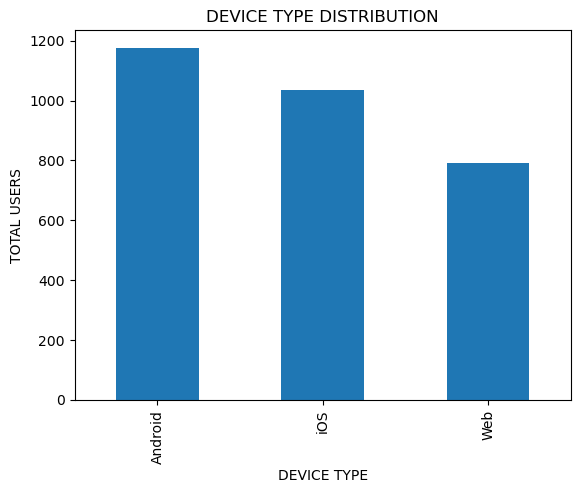

				MAJORITY OF USERS USE ANDROID DEVICES!


In [150]:
# Device Type Distribution:
users['device_type'].value_counts().plot(kind='bar')
plt.title('DEVICE TYPE DISTRIBUTION')
plt.xlabel('DEVICE TYPE')
plt.ylabel('TOTAL USERS')
plt.show()

print('='*100)
print(f'\t\t\t\tMAJORITY OF USERS USE {(users['device_type'].value_counts().idxmax()).upper()} DEVICES!')
print('='*100)

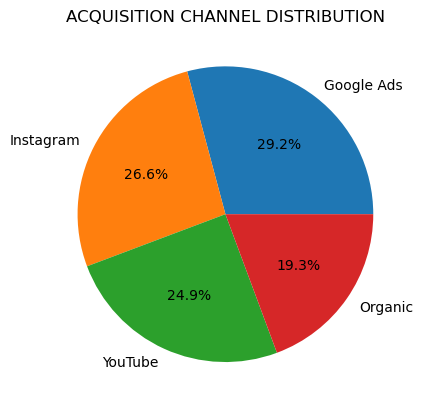

				MAJORITY OF USERS USE GOOGLE ADS CHANNEL!


In [151]:
# Acquisition Channel Distribution:

users['acquisition_channel'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('ACQUISITION CHANNEL DISTRIBUTION')
plt.ylabel('')
plt.show()

print('='*100)
print(f'\t\t\t\tMAJORITY OF USERS USE {(users['acquisition_channel'].value_counts().idxmax()).upper()} CHANNEL!')
print('='*100)

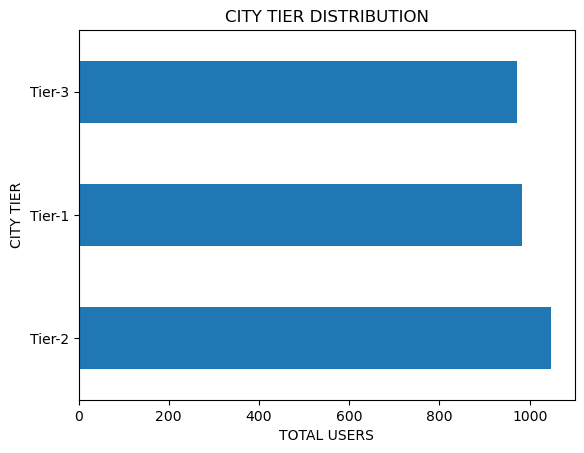

				MOST OF THE USERS BELONG TO TIER-2 CITY!


In [152]:
# City Tier Distribution:

users['city_tier'].value_counts().plot(kind='barh')
plt.title('CITY TIER DISTRIBUTION')
plt.xlabel('TOTAL USERS')
plt.ylabel('CITY TIER')
plt.show()

print('='*100)
print(F'\t\t\t\tMOST OF THE USERS BELONG TO {(users['city_tier'].value_counts().idxmax()).upper()} CITY!')
print('='*100)

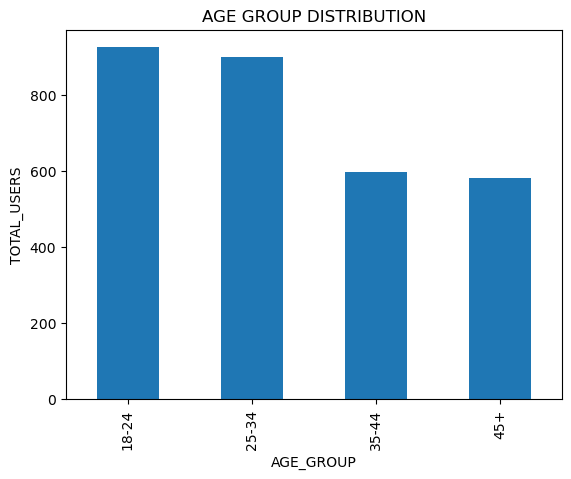

				MOST OF THE USERS BELONGS TO 18-24 AGE GROUP!


In [153]:
# Age Group Distribution:
users['age_group'].value_counts().plot(kind='bar')
plt.title('AGE GROUP DISTRIBUTION')
plt.xlabel('AGE_GROUP')
plt.ylabel('TOTAL_USERS')
plt.show()

print('='*100)
print(f'\t\t\t\tMOST OF THE USERS BELONGS TO {(users['age_group'].value_counts().idxmax()).upper()} AGE GROUP!')
print('='*100)

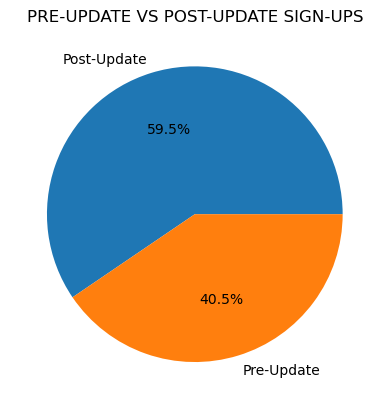

	MOST USERS SIGNED UP POST-UPDATE, SO THE NEW DESIGN HAVENT CHANGED USER SIGN-UPS!


In [154]:
# Pre-Update vs Post-Update sign-ups:
users['signup_period'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('PRE-UPDATE VS POST-UPDATE SIGN-UPS')
plt.ylabel('')
plt.show()

print('='*100)
print(F'\tMOST USERS SIGNED UP {(users['signup_period'].value_counts().idxmax()).upper()}, SO THE NEW DESIGN HAVENT CHANGED USER SIGN-UPS!')
print('='*100)

### SUBSCRIPTIONS TABLE:

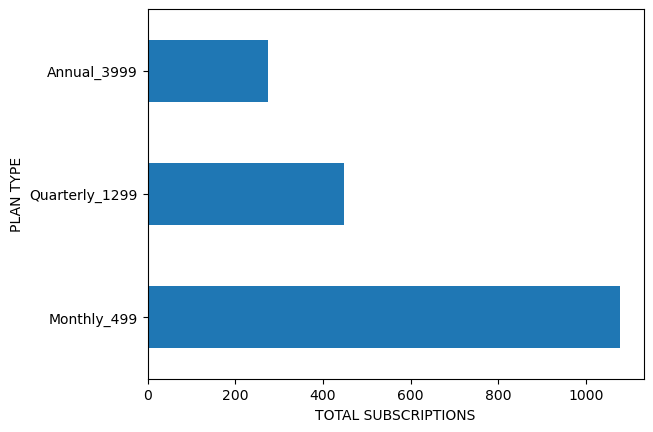

				MONTHLY_499 IS THE MOST POPULAR PLAN!


In [155]:
# Plan type distribution:
subscriptions['plan_type'].value_counts().plot(kind='barh')
plt.xlabel('TOTAL SUBSCRIPTIONS')
plt.ylabel('PLAN TYPE')
plt.show()

print('='*100)
print(f'\t\t\t\t{(subscriptions['plan_type'].value_counts().idxmax()).upper()} IS THE MOST POPULAR PLAN!')
print('='*100)

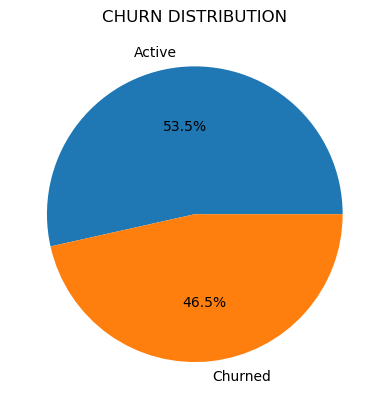

				ALMOST 50% OF SUBSCRIPTIONS ARE ALREADY CHURNED!


In [156]:
# Churn Distribution:
subscriptions['churn_flag'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Active','Churned'])
plt.title('CHURN DISTRIBUTION')
plt.ylabel('')
plt.show()

print('='*100)
print('\t\t\t\tALMOST 50% OF SUBSCRIPTIONS ARE ALREADY CHURNED!')
print('='*100)

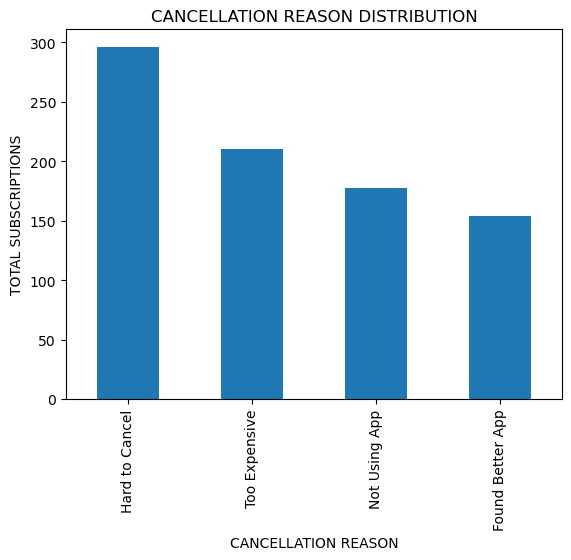

		OVERALL, HARD TO CANCEL IS THE LEADING CANCELLATION REASON!


In [157]:
# Cancellation Reason Distribution:

subscriptions['cancellation_reason'].value_counts().plot(kind='bar')
plt.title('CANCELLATION REASON DISTRIBUTION')
plt.xlabel('CANCELLATION REASON')
plt.ylabel('TOTAL SUBSCRIPTIONS')
plt.show()

print('='*100)
print(f'\t\tOVERALL, {(subscriptions['cancellation_reason'].value_counts().idxmax()).upper()} IS THE LEADING CANCELLATION REASON!')
print('='*100)

### SESSIONS TABLE:

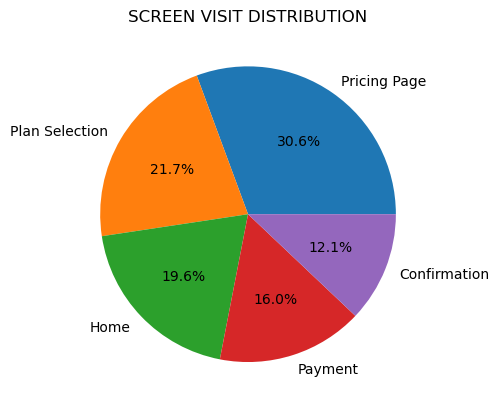

				PRICING PAGE SCREEN IS VISITED THE MOST


In [158]:
# Screen Visit Distribution

sessions['screen_name'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('SCREEN VISIT DISTRIBUTION')
plt.ylabel('')
plt.show()

print('='*100)
print(f'\t\t\t\t{(sessions['screen_name'].value_counts().idxmax()).upper()} SCREEN IS VISITED THE MOST')
print('='*100)

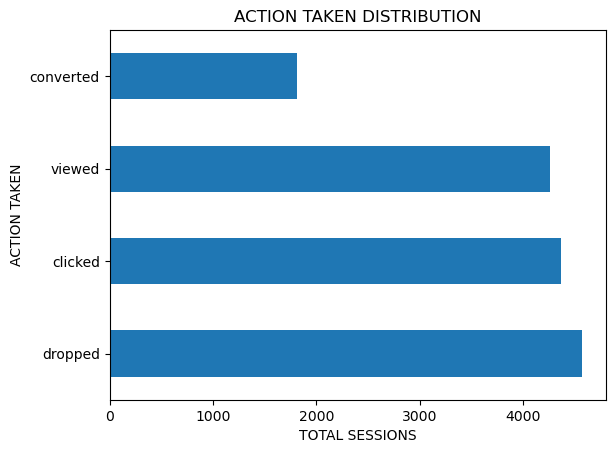

		DROPPED IS THE MOST COMMON ACTIONS TAKEN BY USERS!


In [159]:
# Action Taken Distribution:

sessions['action_taken'].value_counts().plot(kind='barh')
plt.title('ACTION TAKEN DISTRIBUTION')
plt.xlabel('TOTAL SESSIONS')
plt.ylabel('ACTION TAKEN')
plt.show()

print('='*100)
print(f'\t\t{(sessions['action_taken'].value_counts().idxmax()).upper()} IS THE MOST COMMON ACTIONS TAKEN BY USERS!')
print('='*100)

### AB_TEST TABLE:

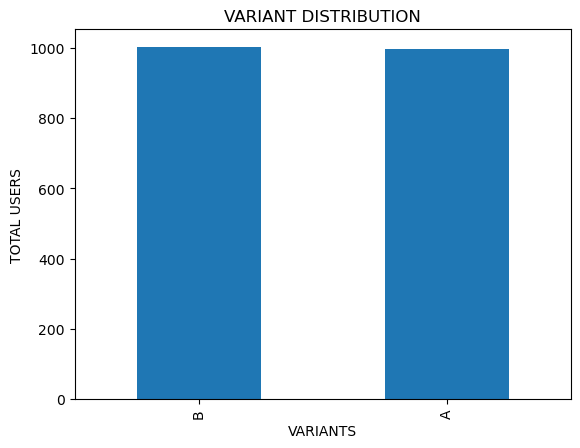

			USERS ARE EVENLY SPREAD ACROSS BOTH VARIANTS A AND B!


In [160]:
# Variant Distribution:
ab_test['variant'].value_counts().plot(kind='bar')
plt.title('VARIANT DISTRIBUTION')
plt.xlabel('VARIANTS')
plt.ylabel('TOTAL USERS')
plt.show()

print('='*100)
print('\t\t\tUSERS ARE EVENLY SPREAD ACROSS BOTH VARIANTS A AND B!')
print('='*100)

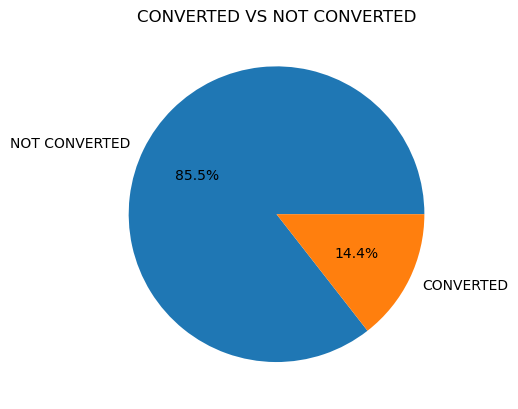

				 ONLY ABOUT 14.4% USERS ARE BEING CONVERTED!


In [161]:
ab_test['converted'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['NOT CONVERTED','CONVERTED'])
plt.title('CONVERTED VS NOT CONVERTED')
plt.ylabel('')
plt.show()

print('='*100)
print(f'\t\t\t\t ONLY ABOUT 14.4% USERS ARE BEING CONVERTED!')
print('='*100)

## 2. Bivariate Analysis:

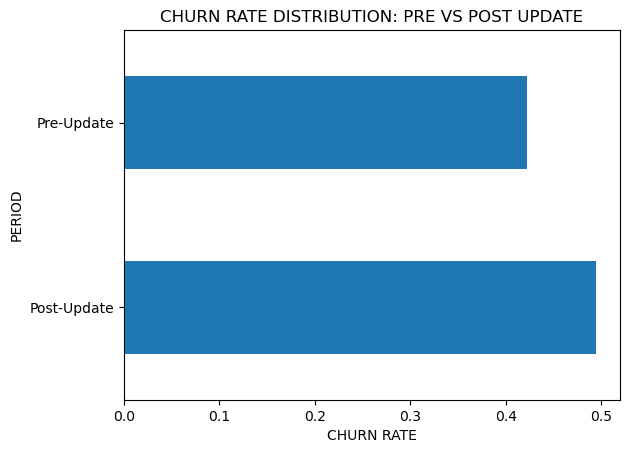

				CHURN RATE PRE-UPDATE:42.3%!
				CHURN RATE POST UPDATE:49.5%!
			 CHURN RATE JUMPED BY 7.2% AFTER MARCH 15 UPDATE!


In [162]:
# Churn Rate: Pre vs Post Update
subscriptions.groupby('subscription_period')['churn_flag'].mean().plot(kind='barh')
plt.title('CHURN RATE DISTRIBUTION: PRE VS POST UPDATE')
plt.xlabel('CHURN RATE')
plt.ylabel('PERIOD')
plt.show()

churn_rate_period=subscriptions.groupby('subscription_period')['churn_flag']

print('='*100)
print(f'\t\t\t\tCHURN RATE PRE-UPDATE:{churn_rate_period.mean()['Pre-Update']:.1%}!')
print(f'\t\t\t\tCHURN RATE POST UPDATE:{churn_rate_period.mean()['Post-Update']:.1%}!')
churn_difference = churn_rate_period.mean()['Post-Update'] - churn_rate_period.mean()['Pre-Update']
print(f'\t\t\t CHURN RATE JUMPED BY {churn_difference:.1%} AFTER MARCH 15 UPDATE!')
print('='*100)

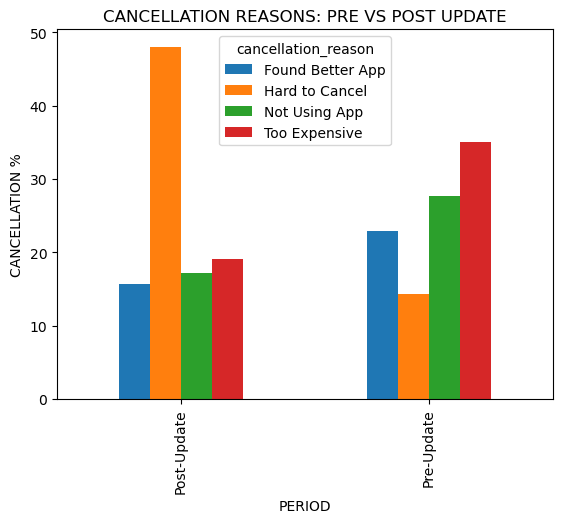

		HARD TO CANCEL REASON INCREASED A LOT BY 33.66% AFTER THE UX UPDATE!


In [163]:
# CANCELLATION REASONS - PRE VS POST UPDATES:

# Calculate period-wise cancel percentages:
cancellations = subscriptions.dropna(subset=['cancellation_reason'])
cancel_percent = pd.crosstab(cancellations['subscription_period'],cancellations['cancellation_reason'],normalize='index')*100

# Plot the graph:
cancel_percent.plot(kind='bar')
plt.title('CANCELLATION REASONS: PRE VS POST UPDATE')
plt.xlabel('PERIOD')
plt.ylabel('CANCELLATION %')
plt.show()

# Calculate cancellation difference:
cancel_difference = cancel_percent.loc['Post-Update'] - cancel_percent.loc['Pre-Update']

print('='*100)
print(f'\t\t{cancel_difference.idxmax().upper()} REASON INCREASED A LOT BY {round(cancel_difference.max(),2)}% AFTER THE UX UPDATE!')
print('='*100)

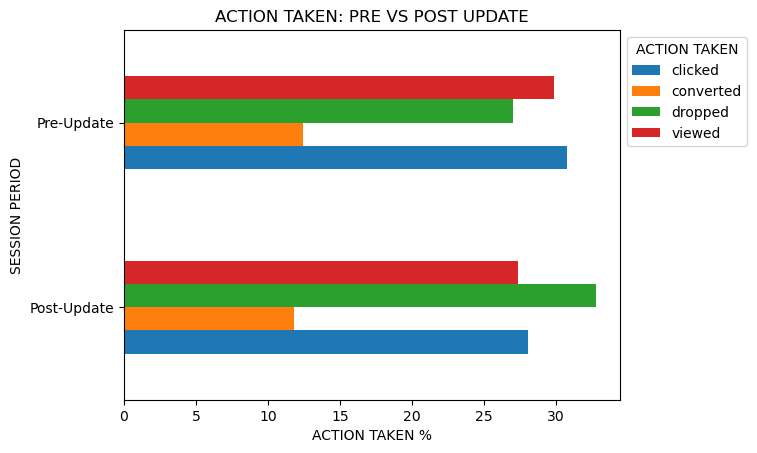

			MOST OF THE SESSIONS ARE DROPPED POST UPDATE BY 5.76% !


In [164]:
# Sessions Action Taken: Pre vs Post Update:

# Calculate action taken-wise percentage:
actions_taken_percent = pd.crosstab(sessions['session_period'], sessions['action_taken'],normalize='index')*100

#Plot the graph:
actions_taken_percent.plot(kind='barh')
plt.title('ACTION TAKEN: PRE VS POST UPDATE')
plt.xlabel('ACTION TAKEN %')
plt.ylabel('SESSION PERIOD')
plt.legend(title='ACTION TAKEN', bbox_to_anchor=(1,1))
plt.show()

# Check each action taken difference pre vs post update:

action_taken_diff = (actions_taken_percent.loc['Post-Update'] - actions_taken_percent.loc['Pre-Update'])

print('='*100)
print(f'\t\t\tMOST OF THE SESSIONS ARE {(action_taken_diff.idxmax()).upper()} POST UPDATE BY {round(action_taken_diff.max(),2)}% !')
print('='*100)

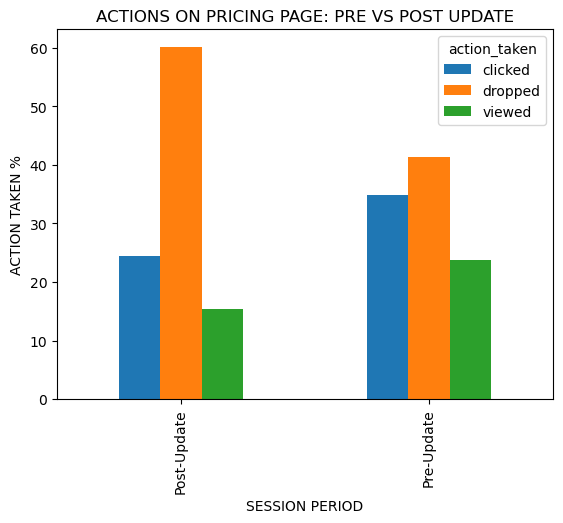

			MOST OF THE SESSIONS ARE DROPPED ON PRICING PAGE BY 18.78% !


In [165]:
# Pricing Page actions: Pre vs post upate:

# Filter only pricing page action taken from sessions:
pricing = sessions[sessions['screen_name'] == 'Pricing Page']
actions = pd.crosstab(pricing['session_period'], pricing['action_taken'],normalize='index')*100

# Plot the graph:
actions.plot(kind='bar')
plt.title('ACTIONS ON PRICING PAGE: PRE VS POST UPDATE')
plt.xlabel('SESSION PERIOD')
plt.ylabel('ACTION TAKEN %')
plt.show()

# Calculate the action-wise difference:
actions_diff = (actions.loc['Post-Update']-actions.loc['Pre-Update'])

print('='*100)
print(f'\t\t\tMOST OF THE SESSIONS ARE {(actions_diff.idxmax()).upper()} ON PRICING PAGE BY {round(actions_diff.max(),2)}% !')
print('='*100)

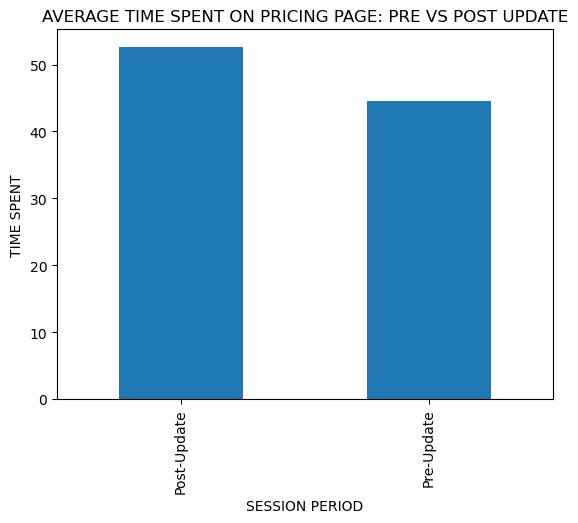

	AVERAGE TIME SPENT ON PRICING PAGE:
	PRE-UPDATE: 44.5s
	POST-UPDATE: 52.6s
	USERS GET CONFUSED AND SPEND MORE TIME ON PRICING PAGE POST UPDATE!


In [166]:
# Average Time Spent on Pricing Page: Pre vs Post update:

# Calculate time spent on pricing page:
pricing_page_time=pricing.groupby('session_period')['time_spent_seconds'].mean()

pricing_page_time.plot(kind='bar')
plt.title('AVERAGE TIME SPENT ON PRICING PAGE: PRE VS POST UPDATE')
plt.xlabel('SESSION PERIOD')
plt.ylabel('TIME SPENT')
plt.show()

print('='*100)
print(f'\tAVERAGE TIME SPENT ON PRICING PAGE:\n\tPRE-UPDATE: {pricing_page_time['Pre-Update']:.1f}s\n\tPOST-UPDATE: {pricing_page_time['Post-Update']:.1f}s')
print(f'\tUSERS GET CONFUSED AND SPEND MORE TIME ON PRICING PAGE POST UPDATE!')
print('='*100)

### Statistical Significance Test: Pricing Page Time (Pre vs Post Update)

In [167]:
# Statistical Significance Test - Pricing Page Time Spent (Pre vs Post Update):
from scipy.stats import ttest_ind

pre_time = pricing[pricing['session_period'] == 'Pre-Update']['time_spent_seconds']
post_time = pricing[pricing['session_period'] == 'Post-Update']['time_spent_seconds']

t_stat_pricing, p_value_pricing = ttest_ind(pre_time, post_time, equal_var=False)  # Welch's t-test

print('='*100)
print('\t\t\tT-TEST: PRICING PAGE TIME SPENT - PRE VS POST UPDATE')
print('='*100)
print(f'T-STATISTIC: {t_stat_pricing:.4f}')
print(f'P-VALUE: {p_value_pricing:.4f}')

if p_value_pricing < 0.05:
    print('\nRESULT: P-VALUE < 0.05, THE INCREASE IN TIME SPENT ON PRICING PAGE POST-UPDATE IS STATISTICALLY SIGNIFICANT!')
else:
    print('\nRESULT: P-VALUE >= 0.05, NOT ENOUGH EVIDENCE TO CONCLUDE THE TIME SPENT DIFFERENCE IS STATISTICALLY SIGNIFICANT.')
print('='*100)


			T-TEST: PRICING PAGE TIME SPENT - PRE VS POST UPDATE
T-STATISTIC: -31.1699
P-VALUE: 0.0000

RESULT: P-VALUE < 0.05, THE INCREASE IN TIME SPENT ON PRICING PAGE POST-UPDATE IS STATISTICALLY SIGNIFICANT!


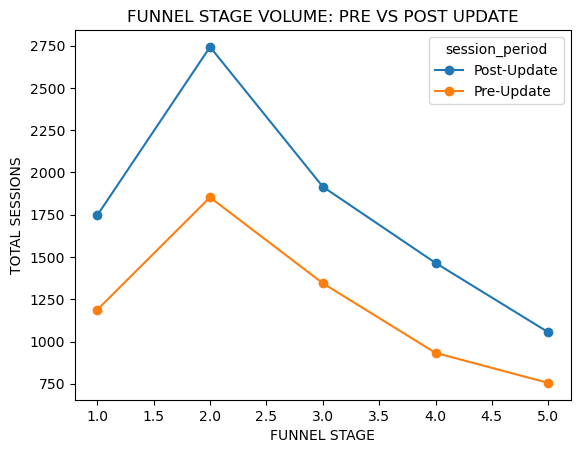

		SESSION TIME DROPS STEADILY AFTER FUNNEL 2 IN BOTH THE PERIODS!


In [168]:
# Funnel stage volume: Pre vs Post Update:

pd.crosstab(sessions['funnel_stage'], sessions['session_period']).plot(kind='line', marker='o')
plt.title('FUNNEL STAGE VOLUME: PRE VS POST UPDATE')
plt.xlabel('FUNNEL STAGE')
plt.ylabel('TOTAL SESSIONS')
plt.show()

print('='*100)
print('\t\tSESSION TIME DROPS STEADILY AFTER FUNNEL 2 IN BOTH THE PERIODS!')
print('='*100)

## 3. AB Test: Variant A vs Variant B:

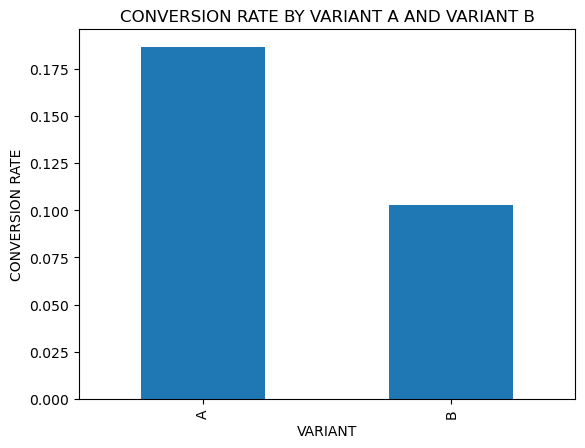

		CONVERSION RATES
		VARIANT A: 18.6%
		VARIANT B: 10.3%
	VARIANT B CONVERTS WORSE THAN VARIANT A!


In [169]:
# Conversion Rate by Variant A vs Variant B:

# Calculate Conversion Rate:
conversion_rate = ab_test.groupby('variant')['converted'].mean()


# Plot the graph:
conversion_rate.plot(kind='bar')
plt.title('CONVERSION RATE BY VARIANT A AND VARIANT B')
plt.xlabel('VARIANT')
plt.ylabel('CONVERSION RATE')
plt.show()

print('='*100)
print(f'\t\tCONVERSION RATES\n\t\tVARIANT A: {conversion_rate['A']:.1%}\n\t\tVARIANT B: {conversion_rate['B']:.1%}')
print(f'\tVARIANT {conversion_rate.idxmin()} CONVERTS WORSE THAN VARIANT {conversion_rate.idxmax()}!')
print('='*100)

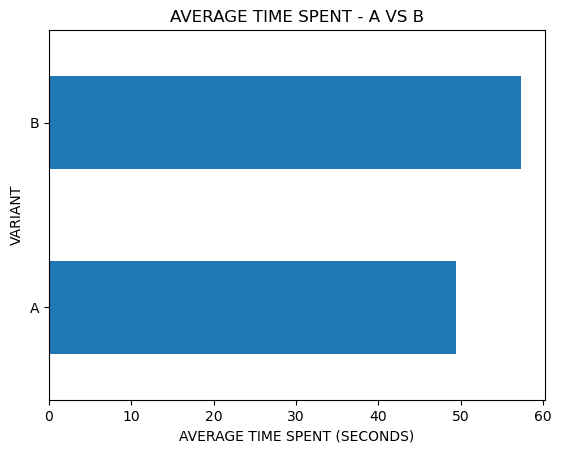

	AVERAGE TIME SPENT:
	VARIANT A: 49.5s
	VARIANT B: 57.4s
	USERS SPEND HIGHEST TIME ON VARIANT B, STILL CONVERTING LESS. ITS A SIGN OF CONFUSING DESIGN!


In [170]:
# Average Time Spent - A vs B:

# Calculate average time spent:
average_time = ab_test.groupby('variant')['time_on_page_seconds'].mean()

# Plot the graph:
average_time.plot(kind='barh')
plt.title('AVERAGE TIME SPENT - A VS B')
plt.xlabel('AVERAGE TIME SPENT (SECONDS)')
plt.ylabel('VARIANT')
plt.show()

print('='*100)
print(f'\tAVERAGE TIME SPENT:\n\tVARIANT A: {average_time['A']:.1f}s\n\tVARIANT B: {average_time['B']:.1f}s')
print(f'\tUSERS SPEND HIGHEST TIME ON VARIANT {average_time.idxmax()}, STILL CONVERTING LESS. ITS A SIGN OF CONFUSING DESIGN!')
print('='*100)

### Statistical Significance Testing: Is Variant B Really Worse?

In [171]:
# Statistical Significance Test - Conversion Rate by Variant (Chi-Square Test):
from scipy.stats import chi2_contingency

# Build contingency table of variant vs converted:
contingency = pd.crosstab(ab_test['variant'], ab_test['converted'])

chi2_stat, p_value_conv, dof, expected = chi2_contingency(contingency)

print('='*100)
print('\t\t\tCHI-SQUARE TEST: CONVERSION RATE BY VARIANT')
print('='*100)
print(f'CHI-SQUARE STATISTIC: {chi2_stat:.4f}')
print(f'P-VALUE: {p_value_conv:.4f}')

if p_value_conv < 0.05:
    print('\nRESULT: P-VALUE < 0.05, THE CONVERSION RATE DIFFERENCE BETWEEN VARIANT A AND B IS STATISTICALLY SIGNIFICANT!')
else:
    print('\nRESULT: P-VALUE >= 0.05, NOT ENOUGH EVIDENCE TO CONCLUDE THE CONVERSION RATE DIFFERENCE IS STATISTICALLY SIGNIFICANT.')
print('='*100)


			CHI-SQUARE TEST: CONVERSION RATE BY VARIANT
CHI-SQUARE STATISTIC: 27.5812
P-VALUE: 0.0000

RESULT: P-VALUE < 0.05, THE CONVERSION RATE DIFFERENCE BETWEEN VARIANT A AND B IS STATISTICALLY SIGNIFICANT!


In [172]:
# Statistical Significance Test - Time on Page by Variant (Welch's T-Test):
from scipy.stats import ttest_ind

variant_a_time = ab_test[ab_test['variant'] == 'A']['time_on_page_seconds']
variant_b_time = ab_test[ab_test['variant'] == 'B']['time_on_page_seconds']

t_stat_ab, p_value_ab = ttest_ind(variant_a_time, variant_b_time, equal_var=False)

print('='*100)
print('\t\t\tT-TEST: TIME ON PAGE BY VARIANT')
print('='*100)
print(f'T-STATISTIC: {t_stat_ab:.4f}')
print(f'P-VALUE: {p_value_ab:.4f}')

if p_value_ab < 0.05:
    print('\nRESULT: P-VALUE < 0.05, THE TIME-ON-PAGE DIFFERENCE BETWEEN VARIANT A AND B IS STATISTICALLY SIGNIFICANT!')
else:
    print('\nRESULT: P-VALUE >= 0.05, NOT ENOUGH EVIDENCE TO CONCLUDE THE TIME-ON-PAGE DIFFERENCE IS STATISTICALLY SIGNIFICANT.')
print('='*100)


			T-TEST: TIME ON PAGE BY VARIANT
T-STATISTIC: -20.8187
P-VALUE: 0.0000

RESULT: P-VALUE < 0.05, THE TIME-ON-PAGE DIFFERENCE BETWEEN VARIANT A AND B IS STATISTICALLY SIGNIFICANT!


## 4. Churn Analysis:

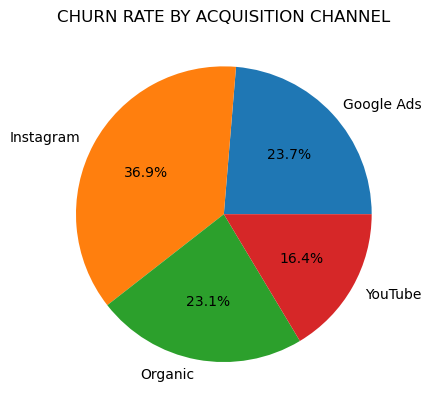

			CHURN RATES:
			INSTAGRAM: 68.0%
			YOUTUBE: 30.2%
			GOOGLE ADS: 43.7%
			ORGANIC: 42.5%
			INSTAGRAM USERS ARE MOSTLY CHURNED!


In [173]:
# Churn Rate By Aquisition Channel:

# Fetch churned channels from subscriptions and users and calculate churn percentage:
churned_channels = subscriptions.merge(users, on='user_id')
churn_channel_percent = churned_channels.groupby('acquisition_channel')['churn_flag'].mean()

# Plot the graph:
churn_channel_percent.plot(kind='pie', autopct='%1.1f%%')
plt.title('CHURN RATE BY ACQUISITION CHANNEL')
plt.ylabel('')
plt.show()

print('='*100)
print(f'\t\t\tCHURN RATES:\n\t\t\tINSTAGRAM: {churn_channel_percent['Instagram']:.1%}\n\t\t\tYOUTUBE: {churn_channel_percent['YouTube']:.1%}')
print(f'\t\t\tGOOGLE ADS: {churn_channel_percent['Google Ads']:.1%}\n\t\t\tORGANIC: {churn_channel_percent['Organic']:.1%}')
print(f'\t\t\t{(churn_channel_percent.idxmax()).upper()} USERS ARE MOSTLY CHURNED!')
print('='*100)

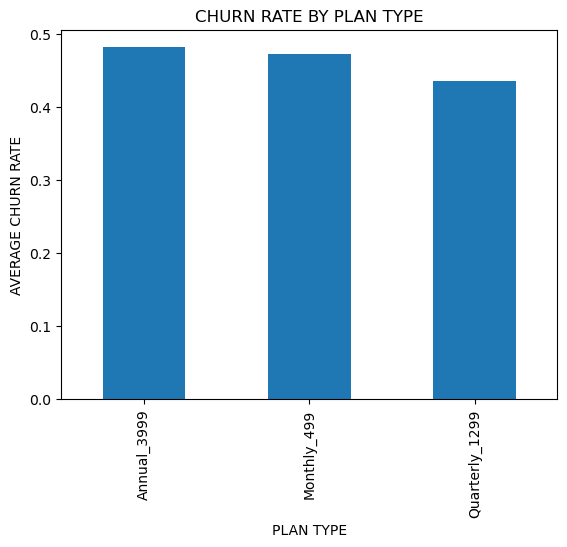

			CHURN RATE PERCENT:
			ANNUAL: 48.2%
			MONTHLY: 47.3%
			QUARTERLY: 43.5%
			Annual_3999 PLAN HAS THE HIGHEST CHURN RATE!


In [174]:
# Churn Rate by Plan Type:

# Calculate Churn Rate Percent:
churn_rate_percent = subscriptions.groupby('plan_type')['churn_flag'].mean()

# Plot the graph:
churn_rate_percent.plot(kind='bar')
plt.title('CHURN RATE BY PLAN TYPE')
plt.xlabel('PLAN TYPE')
plt.ylabel('AVERAGE CHURN RATE')
plt.show()

print('='*100)
print(f'\t\t\tCHURN RATE PERCENT:\n\t\t\tANNUAL: {churn_rate_percent['Annual_3999']:.1%}')
print(f'\t\t\tMONTHLY: {churn_rate_percent['Monthly_499']:.1%}')
print(f'\t\t\tQUARTERLY: {churn_rate_percent['Quarterly_1299']:.1%}')
print(f'\t\t\t{(churn_rate_percent.idxmax())} PLAN HAS THE HIGHEST CHURN RATE!')
print('='*100)

# 5. Revenue Impact:

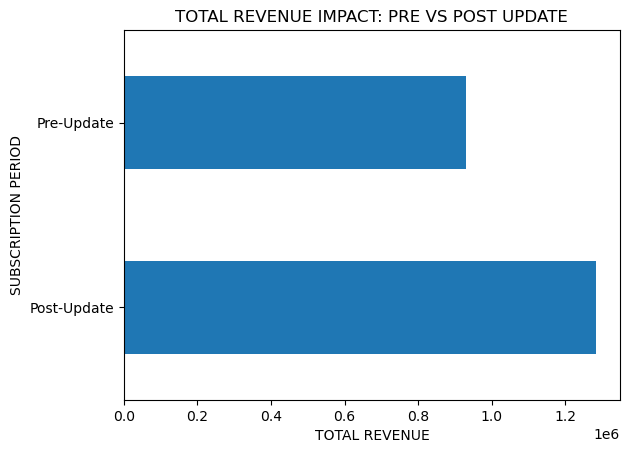

			TOTAL REVENUE:
			PRE-UPDATE: 931157.0
			POST-UPDATE: 1284443.0
	REVENUE WENT UP BY 353286.0 AFTER THE UPDATE DESPITE THE HIGHER CHURN!
THIS INDICATES THAT MOST OF THE USERS WERE BILLED BEFORE THEY COMPLETED THE CANCELLATION!


In [175]:
# Revenue Impact:

# Extracr plan price from plan_type:
subscriptions['plan_price'] = subscriptions['plan_type'].str.extract(r'_(\d+)').astype(float)

# Calculate total revenue by subscription period:
total_revenue = subscriptions.groupby('subscription_period')['plan_price'].sum()

# Plot the graph:
total_revenue.plot(kind='barh')
plt.title('TOTAL REVENUE IMPACT: PRE VS POST UPDATE')
plt.xlabel('TOTAL REVENUE')
plt.ylabel('SUBSCRIPTION PERIOD')
plt.show()

print('='*100)
print(f'\t\t\tTOTAL REVENUE:\n\t\t\tPRE-UPDATE: {total_revenue['Pre-Update']}\n\t\t\tPOST-UPDATE: {total_revenue['Post-Update']}')
print(f'\tREVENUE WENT UP BY {total_revenue['Post-Update'] - total_revenue['Pre-Update']} AFTER THE UPDATE DESPITE THE HIGHER CHURN!')
print(f'THIS INDICATES THAT MOST OF THE USERS WERE BILLED BEFORE THEY COMPLETED THE CANCELLATION!')
print('='*100)

# Key Insights:

1. **Churn rose from 42.3% Pre-Update to 49.5% Post-Update!**
2. **'Hard to Cancel' complaints increased a lot from 14.3% to 48.0% of all cancellation reasons. Strongest signal of dark pattern!**
3. **Users spend more time on Pricing Page without converting!. This points to more confusing page layout!**
4. **The new UX Design(Variant B) converts very worse than the old design(Variant A), despite users spending more time on it! Its statistically significant!**
5. **Instagram channel users churned the most! This suggests worst app experience!**
6. **Revenue still increased after the new update despite the higher churn! App is extracting more money from users, rather than improving the product!**